# Control systems development

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct


np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

T = 0.0533333

servo_delay = ct.StateSpace(-10, 10, 1, 0)

## Longitudinal system

In [43]:
longitudinal_linear_matrices = np.load("longitudinal_linear.npz")
A = longitudinal_linear_matrices["A"]
B = longitudinal_linear_matrices["B"]
C = longitudinal_linear_matrices["C"]
D = longitudinal_linear_matrices["D"]

longitudinal_linear = ct.StateSpace(A, B, C, D)

### PID controller

In [44]:
P_gain = 0.6
I_gain = 1
D_gain = 0.12

longitudinal_controller = ct.StateSpace(np.zeros((1,1)), np.array([0, 0, 1]), np.array([[-I_gain]]), np.array([[0, -D_gain, -P_gain]]))

Final states:
v (m/s): -1.7655627960575448
alpha (deg): 0.5111409640363939
q (deg/s): 0.0017421890060097182
theta (deg): 1.9891659665503951
Final control input:
delta_e (deg): -1.4857011125773092
Climb rate (m/s): 0.2735259938711549


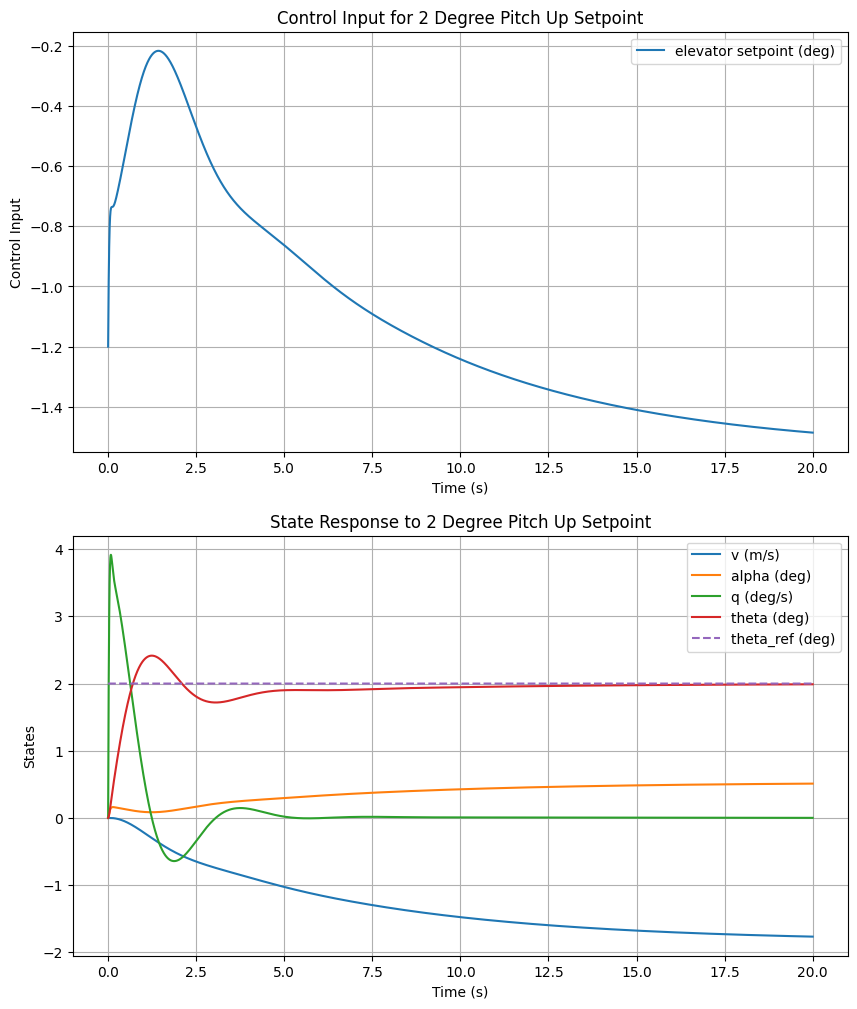

In [45]:
longitudinal_feedback = ct.feedback(longitudinal_controller, longitudinal_linear, sign=-1)

t = np.linspace(0, 20, 10000)
u = np.zeros((3, len(t)))
u[2,:] = 2 * np.pi / 180

# run longitudinal feedback with setpoint tracking
t, y, x = ct.forced_response(longitudinal_feedback, T=t, U=u, return_states = True)

print("Final states:")
print("v (m/s):", x[1, -1])
print("alpha (deg):", x[2, -1] * 180 / np.pi)
print("q (deg/s):", x[3, -1] * 180 / np.pi)
print("theta (deg):", x[4, -1] * 180 / np.pi)

print("Final control input:")
print("delta_e (deg):", y[0, -1] * 180 / np.pi)

print("Climb rate (m/s):", (12.37 + x[1, -1]) * np.sin(x[4, -1] - x[2, -1]))
# plot output
plt.figure(figsize=(10, 12))
plt.subplot(2, 1, 1)
plt.plot(t, y[0, :] * 180 / np.pi, label="elevator setpoint (deg)")
plt.xlabel("Time (s)")
plt.ylabel("Control Input")
plt.title("Control Input for 2 Degree Pitch Up Setpoint")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)

# plot states
plt.plot(t, x[1, :], label="v (m/s)")
plt.plot(t, x[2, :] * 180 / np.pi, label="alpha (deg)")
plt.plot(t, x[3, :] * 180 / np.pi, label="q (deg/s)")
plt.plot(t, x[4, :] * 180 / np.pi, label="theta (deg)")
# reference
plt.plot(t, u[2, :] * 180 / np.pi, label="theta_ref (deg)", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("States")
plt.title("State Response to 2 Degree Pitch Up Setpoint")
plt.legend()
plt.grid()
plt.show()

### Climb rate lookup table

Climb rate for -10 degree pitch up setpoint: -2.73 m/s
Climb rate for -9 degree pitch up setpoint: -2.35 m/s
Climb rate for -8 degree pitch up setpoint: -2.00 m/s
Climb rate for -7 degree pitch up setpoint: -1.67 m/s
Climb rate for -6 degree pitch up setpoint: -1.37 m/s
Climb rate for -5 degree pitch up setpoint: -1.08 m/s
Climb rate for -4 degree pitch up setpoint: -0.82 m/s
Climb rate for -3 degree pitch up setpoint: -0.58 m/s
Climb rate for -2 degree pitch up setpoint: -0.36 m/s
Climb rate for -1 degree pitch up setpoint: -0.17 m/s
Climb rate for 0 degree pitch up setpoint: 0.00 m/s
Climb rate for 1 degree pitch up setpoint: 0.15 m/s
Climb rate for 2 degree pitch up setpoint: 0.27 m/s
Climb rate for 3 degree pitch up setpoint: 0.38 m/s
Climb rate for 4 degree pitch up setpoint: 0.46 m/s
Climb rate for 5 degree pitch up setpoint: 0.51 m/s
Climb rate for 6 degree pitch up setpoint: 0.55 m/s
Climb rate for 7 degree pitch up setpoint: 0.56 m/s
Climb rate for 8 degree pitch up setpoint: 

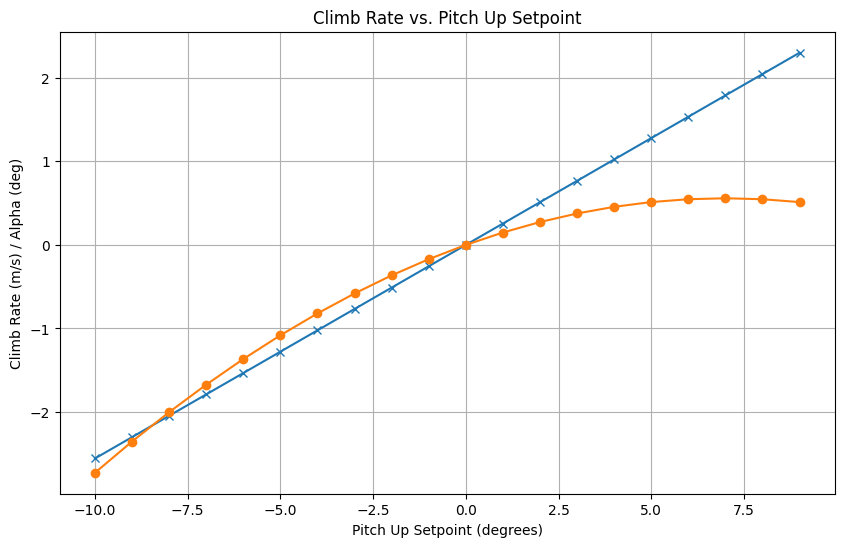

In [ ]:
theta_refs = [i for i in range(-10, 10, 1)]
climb_rates = []
alphas = []

for theta_ref in theta_refs:
    u[2, :] = theta_ref * np.pi / 180
    t, y, x = ct.forced_response(longitudinal_feedback, T=t, U=u, return_states = True)
    climb_rate = (12.37 + x[1, -1]) * np.sin(x[4, -1] - x[2, -1])
    climb_rates.append(climb_rate)
    alphas.append(x[2, -1] * 180 / np.pi)
    print(f"Climb rate for {theta_ref} degree pitch up setpoint: {climb_rate:.2f} m/s")

plt.figure(figsize=(10, 6))
plt.plot(theta_refs, alphas, marker='x', label="alpha (deg)")
plt.plot(theta_refs, climb_rates, marker='o', label="climb rate (m/s)")
plt.xlabel("Pitch Up Setpoint (degrees)")
plt.ylabel("Climb Rate (m/s) / Alpha (deg)")
plt.title("Climb Rate vs. Pitch Up Setpoint")
plt.grid()
plt.legend()
plt.show()


### Stability map

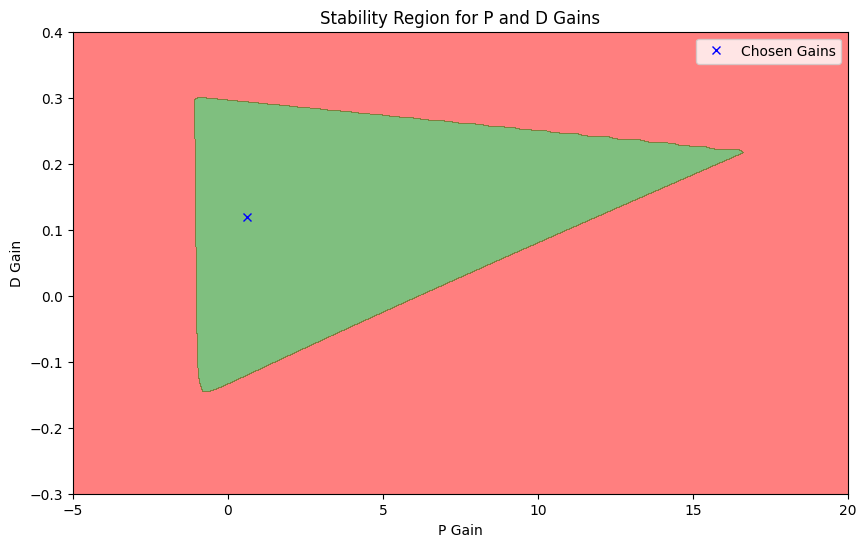

In [47]:
# try all the different gains
kps, kds = np.meshgrid(np.linspace(-5, 20, 150), np.linspace(-0.3, 0.4, 150), indexing="ij")
longitudinal_discrete = ct.sample_system(longitudinal_linear, T)

stability_results = np.zeros(kps.shape)

for i, (kp, kd) in enumerate(zip(kps.flatten(), kds.flatten())):
    longitudinal_controller = ct.StateSpace(np.zeros((1,1)), np.array([0, 0, 1]), np.array([[-I_gain]]), np.array([[0, -kd, -kp]]), dt=T)
    longitudinal_feedback = ct.feedback(longitudinal_controller, longitudinal_discrete, sign=-1)

    # check stability
    A = longitudinal_feedback.A
    eigenvalues = np.linalg.eigvals(A)
    if np.max(np.abs(eigenvalues)) < 1:
        stability_results[i // kps.shape[1], i % kps.shape[1]] = 1
    else:
        stability_results[i // kps.shape[1], i % kps.shape[1]] = 0
    stability_results[i // kps.shape[1], i % kps.shape[1]] = 1 - np.max(np.abs(eigenvalues))

plt.figure(figsize=(10, 6))
plt.contourf(kps, kds, stability_results, levels=[-10, 0, 1], colors=["red", "green"], alpha=0.5)
# show the point we chose
plt.plot(P_gain, D_gain, "x", color="blue", label="Chosen Gains")
plt.legend()
plt.xlabel("P Gain")
plt.ylabel("D Gain")
plt.title("Stability Region for P and D Gains")
plt.show()